In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import Functions as f
import importlib
import numpy as np
import Filtering as fil
importlib.reload(f)
importlib.reload(fil)

<module 'Filtering' from '/Users/james/Desktop/DATA3001/Filtering.py'>

In [2]:
# Load datasets

f12024 = pd.read_csv('UNSW F12024.csv')
left = pd.read_csv('f1sim-ref-left.csv')
right = pd.read_csv('f1sim-ref-right.csv')
line = pd.read_csv('f1sim-ref-line.csv')
turns = pd.read_csv('f1sim-ref-turns.csv')

/var/folders/ng/t1t6hw391s14957cdp0_2k5c0000gn/T/ipykernel_13067/956444696.py:3: DtypeWarning: Columns (70,71,73,74,82) have mixed types. Specify dtype option on import or set low_memory=False.
  f12024 = pd.read_csv('UNSW F12024.csv')


In [53]:
df = f12024.copy()
print(df.shape)
df, left, right, line, turns = fil.filter_track_section(df, left, right, line, turns)
print(df.shape)
df = fil.keep_relevant_features(df)
print(df.shape)
df = fil.remove_nan(df)
print(df.shape)
df = fil.remove_nondriving_behaviour(df)
print(df.shape)

(6525414, 89)
(769835, 89)
(769835, 12)
(673069, 12)
(651435, 12)


# Faulty Racing Data

There is some racing sessions with faulty racing data. This includes:
- sessions where the car's racing position is stagnant (coordinates unchanged for a period of time)
- sessions with low racing data, leading to incomplete trajectories

We remove these from our data to avoid faulty analysis down the line.

# Stagnant Example

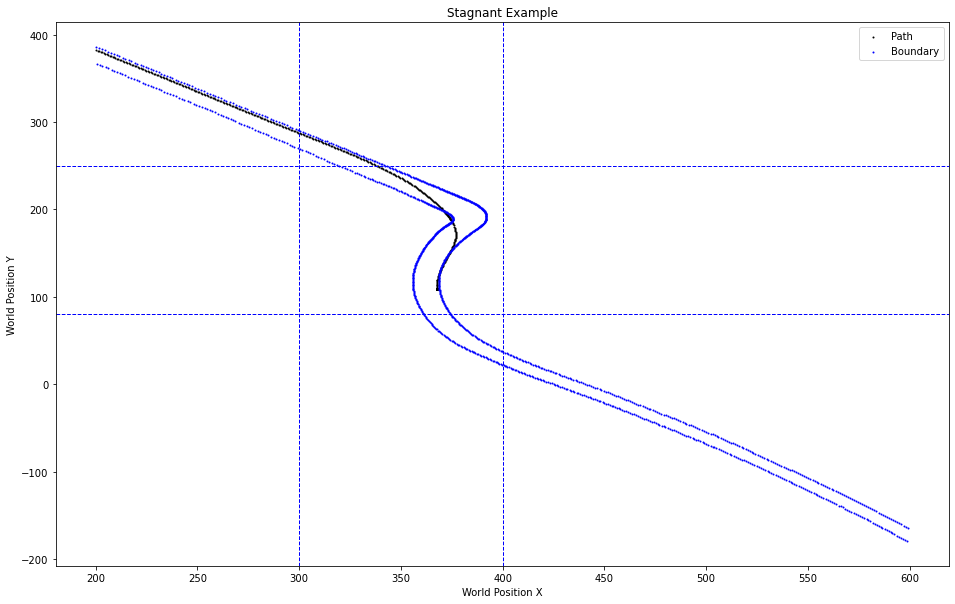

In [56]:
# Stagnant Example
example_session = '212F4920E1E312BFE0631218000A84D4'
example_lap = 1

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Stagnant Example")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()

# Incomplete Paths

We look at the distribution of data points per lap. Some findings:

- data counts outside the range 160 to 220 either have incomplete paths, or weird anomalies

In [28]:
# Removing duplicate coordinates
df = fil.dedupe_xyz(df)

In [52]:
# Further sectioning
x_lower = 300
x_upper = 400
y_lower = 80
y_upper = 250

sdf = df[
        (df["M_WORLDPOSITIONX_1"].between(x_lower, x_upper)) &
        (df["M_WORLDPOSITIONY_1"].between(y_lower, y_upper))
    ]

# 1. Compute row counts per (SESSION_GUID, M_CURRENTLAPNUM)
lap_counts = (
    sdf.groupby(["SESSION_GUID", "M_CURRENTLAPNUM"])
      .size()
      .reset_index(name="row_count")
)

counts_list = lap_counts["row_count"].tolist()

# 2. Find the mode (most common number of samples per lap)
mode_count = lap_counts["row_count"].mode()[0]

# 3. Filter laps that have fewer samples than the mode
incomplete_laps = lap_counts[~lap_counts["row_count"].between(160,220)]

# 4. Display results
print(f"Mode count: {mode_count}")
print(f"{len(incomplete_laps)} laps outside the range.\n")
print(incomplete_laps.head())

Mode count: 192
309 laps outside the range.

                        SESSION_GUID  M_CURRENTLAPNUM  row_count
9   211C1464D105F8D6E0631218000A785F                1        149
10  211C1464D105F8D6E0631218000A785F                2        156
14  211C98F7A4BA963EE0631218000AB662                1        146
64  212FF31C9AF38FBDE0631218000A73E8                1        122
65  212FF31C9AF38FBDE0631218000A73E8                2        115


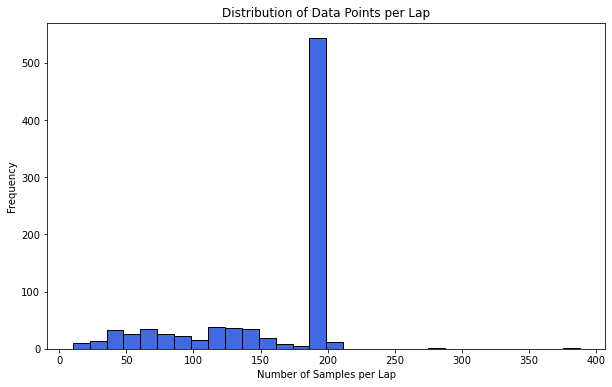

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(lap_counts["row_count"], bins=30, color="royalblue", edgecolor="black")
plt.xlabel("Number of Samples per Lap")
plt.ylabel("Frequency")
plt.title("Distribution of Data Points per Lap")
plt.show()

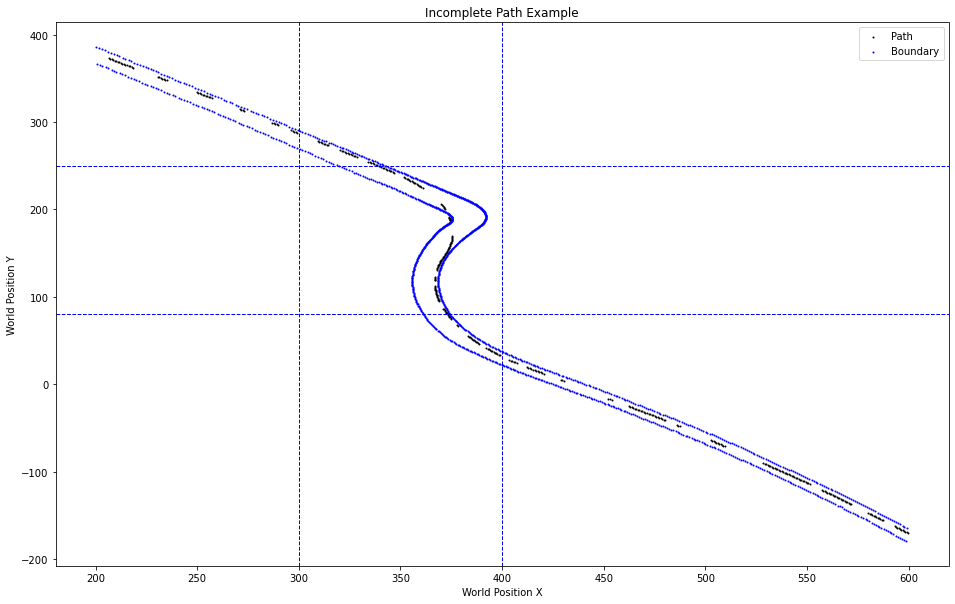

In [51]:
# Incomplete Paths 
example_session = '212FF31C9AF38FBDE0631218000A73E8'
example_lap = 2

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Incomplete Path Example")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()

# Anomalies

Laps with high data counts seemed suspicious and turns out it corresponds to faulty data.

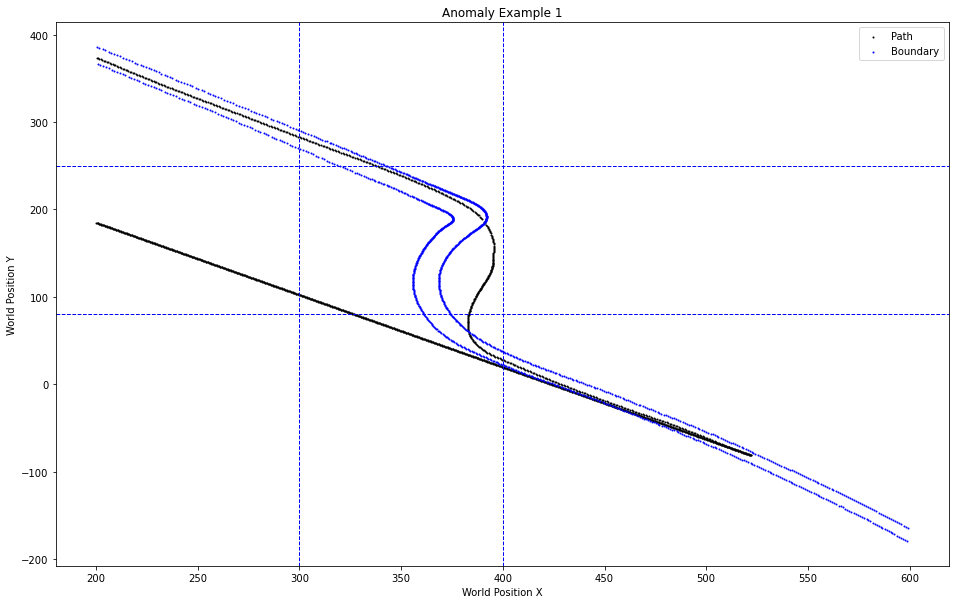

In [43]:
# Anomaly Example 1
example_session = '2416D90E4C467872E0631418000A832C'
example_lap = 3

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Anomaly Example 1")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()

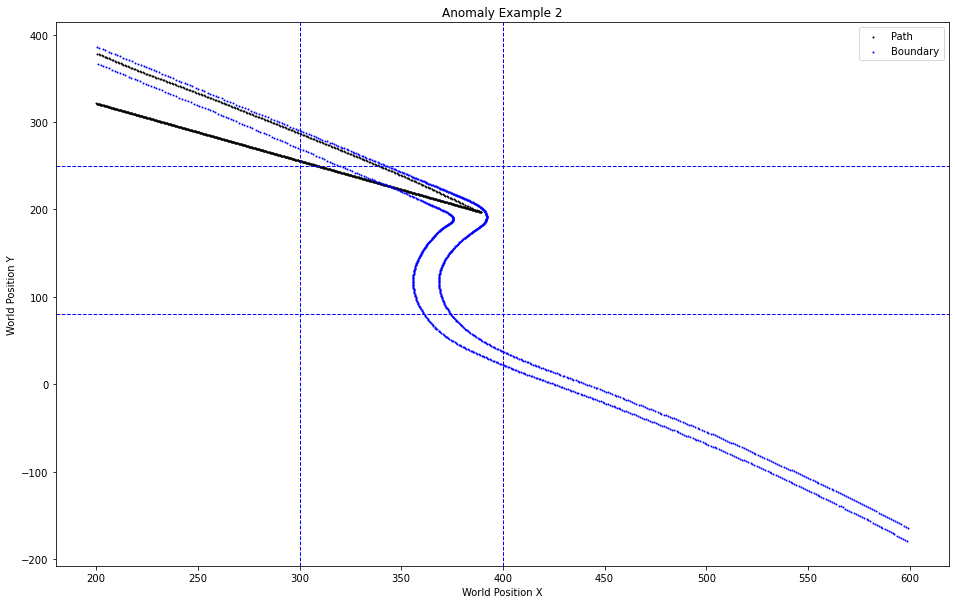

In [44]:
# Anomaly Example 2
example_session = '24DC38837A340381E0631318000A8139'
example_lap = 10

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Anomaly Example 2")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)

plt.show()